In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

Transmonin diagonalisaatio

In [2]:
# Fysikaalisten vakioiden määrittely

phi_zero = 2.0678e-15 #Magneettivuon kvantti
hbar = 1.055e-34 #redusoitu Planckin vakio  

In [3]:
class Transmon:

    def __init__(self,E_C,E_J,N):

        self.E_C=E_C #Varausenergia
        self.E_J=E_J #Josephsonin energia
        self.N=N   

        self.phi = np.linspace(-np.pi, np.pi, N, endpoint=False) #vaiheoperaattori diskretisoituna välillä [-pi,pi] 1000 pisteeseen
        self.delta_phi = self.phi[2]-self.phi[1] #vaiheoperaattorin diskresitoitu askelväli

        M = np.eye(N,k=1)+np.eye(N,k=-1)-2*np.eye(N) #Muodostetaan numero-operaattorin neliön matriisiesitys differenssimenetelmällä
        M[0,-1]=1
        M[-1,0]=1
        n_squared = -M/(self.delta_phi**2)

        self.H_0 = 4*E_C*n_squared-E_J*np.diag(np.cos(self.phi)) #Hamiltonin operaattori

        energies, eigenstates = np.linalg.eigh(self.H_0) # Transmonin ominaisenergiat ja -tilat

        self.energies = energies #Ominaisenergiat
        self.eigenstates = eigenstates #Ominaistilat
        self.frequency = energies[1]-energies[0] #Kubitin taajuus

    def H_D_phibasis(self,A,f_d): #Ajettu Hamiltonin operaattori phi-kannassa (n_g:n muutos)

        M=np.eye(self.N,k=1)-np.eye(self.N,k=-1)
        M[0,-1]=1
        M[-1,0]=-1

        def n_g(t): return (A/(8*self.E_C)) * np.cos(f_d * t)
        def offset_term(t): return 1j * n_g(t) * M / self.delta_phi
        def H_t(t): return self.H_0 + 4 * self.E_C * offset_term(t)

        return H_t
    
    def H_D_eigbasis(self,A,f_d,dim): #Ajettu Hamiltonin operaattori ominaiskannassa
 
        H_0 = np.diag(self.energies[0:dim]-self.energies[0]) #Diagonaalimatriisi ominaisenergioista (lukumäärä ensimmäiset dim)

        M = np.zeros((dim, dim))
        vals = np.sqrt(np.arange(1, dim))
        M[np.arange(dim-1), np.arange(1, dim)] = vals      
        M[np.arange(1, dim), np.arange(dim-1)] = vals

        def H_t(t): return H_0 + A*np.cos(f_d*t)*M

        return H_t
    

class time_evolution:

    def __init__(self,generator):
        self.generator = generator
    
    def U(self, t, dt): return expm(-1j * self.generator(t) * dt) #Aikaevoluutio-operaattori

    def U_floquet(self, period, N): #Floquet-operaattori

        t_vals_floquet=np.linspace(0,period,N)
        delta_t_floquet = t_vals_floquet[1]-t_vals_floquet[0]

        U_f = self.U(0, 0) #Aikakehitysoperaattori yhdelle Floquet-jaksolle
        for i in range(1, N): 
            U_f = self.U(t_vals_floquet[i-1]+delta_t_floquet/2, delta_t_floquet) @ U_f
        return U_f

Transmonin määrittely

In [4]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=Transmon(E_C,E_J,1000)

In [5]:
print("Transmonin seitsemän ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:7]-qubit.energies[0])

Transmonin seitsemän ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.05672712  7.73043296 11.07460509 13.12340606 17.41564073
 17.57885855]


Schrödingerin yhtälön numeerinen ratkaisu aliharmonisessa ajossa

In [6]:
f_d = qubit.frequency/3 #Ajotaajuus

N  = 20 #Floquet-operaattorin laskemiseen käytettyjen aika-askelten määrä
dim  = 7 #Hamiltonin operaattorin dimensio (ominaisenergioiden määrä)

#alpha=qubit.energies[2]-2*qubit.energies[1]+qubit.energies[0]
#eta=A*(qubit.frequency-alpha)/((f_d**2-(qubit.frequency-alpha)**2)*2)

In [7]:
def find_params_eigenbasis(q, A, K, N, dim):
    excited_max=[] #e-tason suurin itseisarvo aikakehityksen aikana

    min_range = -2500
    max_range = -200

    #Etsitään optimaalinen ajotaajuus välillä [f_q+min_range/10000,f_q+max_range/10000]
    for i in range(min_range,max_range):

        f_d_shifted=f_d+i/10000 #Siirretty ajotaajuus
        evolution=time_evolution(q.H_D_eigbasis(A,f_d_shifted,dim)) #Määritellään aikaevoluutio Hamiltonin operaattorin ominaiskannassa
        U_floquet=evolution.U_floquet(2*np.pi/f_d_shifted,N) #Määritellään Floquet-operaattori

        psi = np.zeros((K, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
        psi[0,0] = 1

        for j in range(1, K): #Aikakehitys
            psi[j] = U_floquet @ psi[j-1]

        excited_max.append(max(np.abs(psi[:, 1])))

    delta=(np.argmax(excited_max)+min_range)/10000 #Valitaan ajotaajuus suurimman e-tason saavuttaman todennäköisyyden perusteella

    T_d=2*np.pi/(f_d+delta) #Ajavan kentän jaksonaika

    evolution=time_evolution(qubit.H_D_eigbasis(A,f_d+delta,dim))
    U_floquet=evolution.U_floquet(T_d,N)

    psi = np.zeros((K*100, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0,0] = 1

    for i in range(1, K*100): #Aikakehitys
        psi[i] = U_floquet @ psi[i-1]

    prob_g = np.abs(psi[:, 0])**2
    prob_e = np.abs(psi[:, 1])**2
    prob_f = np.abs(psi[:, 2])**2
    max_vals=np.array([max(prob_g),max(prob_e),max(prob_f)]) #Suurimmat tasojen todennäköisyydet

    prob_g_offset = prob_g-0.5 #Siirretään e-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(prob_g_offset) #Fourier-muunnos
    freqs = np.fft.rfftfreq(len(prob_e), d=T_d) #Taajuusavaruus diskretoituna 1/T_d välein (GHz)

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin e-tason aikakehityksen taajuuskomponentti=Rabi-taajuus

    return[delta,frequency,max_vals]

In [ ]:
deltas = [] #AC Stark siirtymät
rabis = [] #Rabi-taajuudet
max_vals = [] #Suurimmat tasojen todennäköisyydet

#Etsitään rabi-taajuus ja AC Stark siirtymä kun ajavan kentän amplitudi on välillä [0.2*f_q,0.4*f_q] (hbar=1)
for i in range (35,56):
    A = qubit.frequency*(i/100)
    K = 10000 #Aikakehityksen laskemiseen käytettyjen Floquet-jaksojen määrä
    params=find_params_eigenbasis(qubit, A, K, N, dim)
    deltas.append(params[0])
    rabis.append(params[1])
    max_vals.append(params[2])
    print(i)

35


36


37


38


39


...

51


52


53


54


55


[1.41985449 1.46042176 1.50098903 1.5415563  1.58212358 1.62269085
 1.66325812 1.70382539 1.74439266 1.78495993 1.8255272  1.86609447
 1.90666175 1.94722902 1.98779629 2.02836356 2.06893083 2.1094981
 2.15006537 2.19063264 2.23119991]


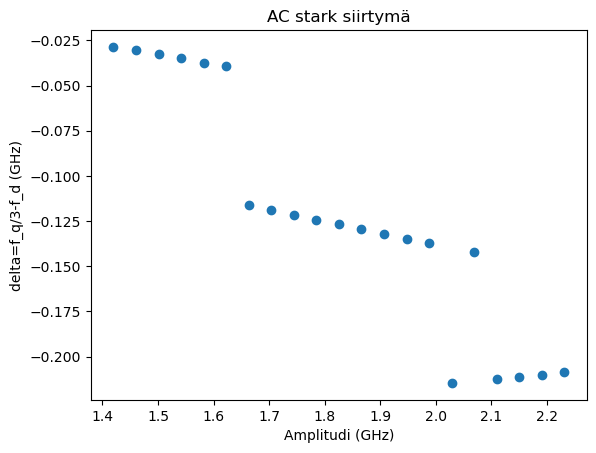

[np.float64(-0.0286), np.float64(-0.0305), np.float64(-0.0325), np.float64(-0.035), np.float64(-0.0373), np.float64(-0.0391), np.float64(-0.1163), np.float64(-0.119), np.float64(-0.1216), np.float64(-0.1243), np.float64(-0.1269), np.float64(-0.1295), np.float64(-0.1323), np.float64(-0.1349), np.float64(-0.1374), np.float64(-0.2146), np.float64(-0.1421), np.float64(-0.2125), np.float64(-0.2113), np.float64(-0.21), np.float64(-0.2087)]


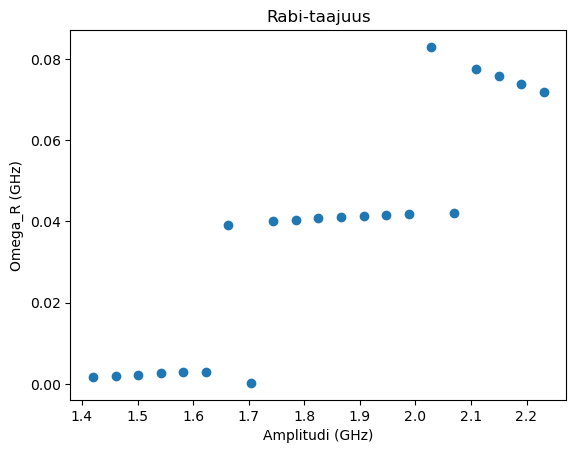

[np.float64(0.0017961231951033106), np.float64(0.0019923579480396214), np.float64(0.0022066542313630756), np.float64(0.0025944905187737367), np.float64(0.0028932273887633466), np.float64(0.0029800744057214843), np.float64(0.03922208322714485), np.float64(0.00025384455218080865), np.float64(0.04004389827069953), np.float64(0.04043846951692638), np.float64(0.04076932979709222), np.float64(0.041072481730334474), np.float64(0.04144402377716661), np.float64(0.04168405709139538), np.float64(0.0418744376379277), np.float64(0.08298486076342743), np.float64(0.041997539186973985), np.float64(0.07752250725805186), np.float64(0.07573284192286632), np.float64(0.07384161905413804), np.float64(0.07195168253414146)]


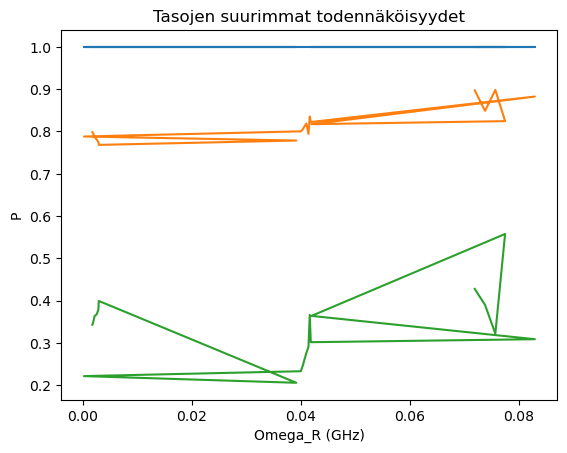

In [9]:
A_vals=(np.arange(21)*0.01+0.35)*qubit.frequency
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=f_q/3-f_d (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Omega_R (GHz)")
plt.title("Rabi-taajuus")
plt.show()
print(rabis)

g_vals=[arr[0] for arr in max_vals]
e_vals=[arr[1] for arr in max_vals]
f_vals=[arr[2] for arr in max_vals]

plt.figure()
plt.plot(rabis, g_vals)
plt.plot(rabis, e_vals)
plt.plot(rabis, f_vals)
plt.xlabel("Omega_R (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

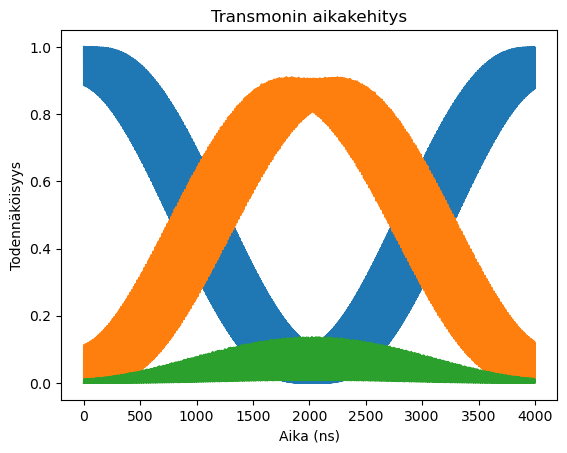

In [10]:
T_d=0.1

K=40000
t_vals = np.arange(K)*T_d #Diskretisoidaan aika
delta_t=(t_vals[1]-t_vals[0])

evolution=time_evolution(qubit.H_D_eigbasis(qubit.frequency*0.2,f_d-0.0085,dim))

psi = np.zeros((K, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
psi[0,0] = 1

for i in range(1, K): #Aikakehitys
    psi[i] = evolution.U(t_vals[i-1]+delta_t/2, delta_t)  @ psi[i-1]

prob_e = np.abs(psi[:, 1])**2
prob_g = np.abs(psi[:, 0])**2
prob_f = np.abs(psi[:, 2])**2

plt.figure()
plt.plot(t_vals,prob_g)
plt.plot(t_vals,prob_e)
plt.plot(t_vals,prob_f)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Transmonin aikakehitys")
plt.show()
